In [1]:
!pip install prophet scikit-learn xgboost statsmodels plotly --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='darkgrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [3]:
df = pd.read_csv('Afficionado Coffee Roasters.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nMissing Values:')
print(df.isnull().sum())
df.head()

Shape: (149116, 11)
Columns: ['transaction_id', 'year', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']

Missing Values:
transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df['time_parsed'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['time_mins']   = df['time_parsed'].dt.hour * 60 + df['time_parsed'].dt.minute

# Detect day boundaries
day_num = [0]
for i in range(1, len(df)):
    if df['time_mins'].iloc[i] - df['time_mins'].iloc[i-1] < -60:
        day_num.append(day_num[-1] + 1)
    else:
        day_num.append(day_num[-1])

df['day_num'] = day_num
df['date']    = pd.Timestamp('2025-01-01') + pd.to_timedelta(df['day_num'], unit='D')
df['revenue'] = df['transaction_qty'] * df['unit_price']
df['hour']    = df['time_parsed'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()

print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Total days:', df['date'].nunique())
print('Stores:', df['store_location'].unique())
df[['transaction_id','date','hour','store_location','revenue']].head()

Date range: 2025-01-01 to 2025-06-30
Total days: 181
Stores: ['Lower Manhattan' "Hell's Kitchen" 'Astoria']


,transaction_id,date,hour,store_location,revenue
0,1,2025-01-01,7,Lower Manhattan,6.0
1,2,2025-01-01,7,Lower Manhattan,6.2
2,3,2025-01-01,7,Lower Manhattan,9.0
3,4,2025-01-01,7,Lower Manhattan,2.0
4,5,2025-01-01,7,Lower Manhattan,6.2


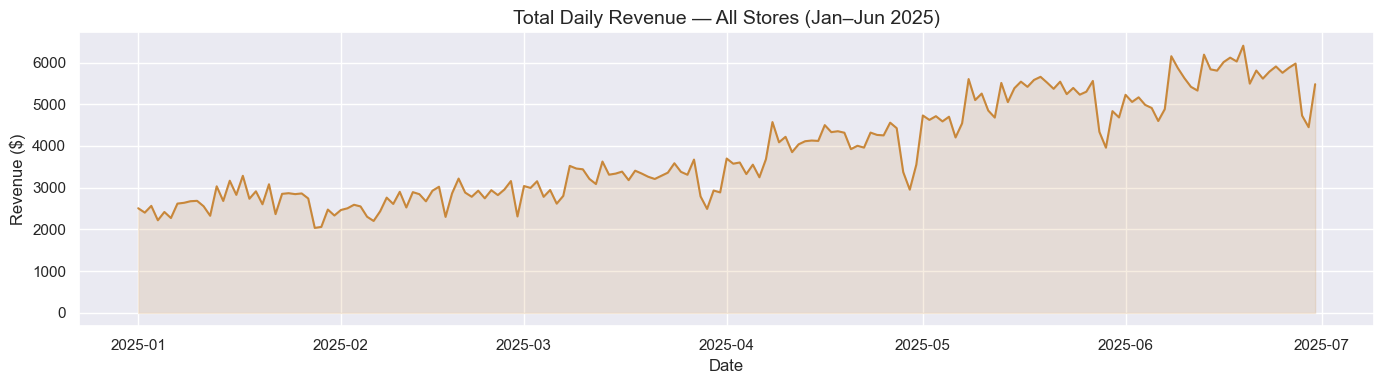

In [5]:
daily_total = df.groupby('date')['revenue'].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily_total.index, daily_total.values, color='#c8873a', linewidth=1.5)
plt.fill_between(daily_total.index, daily_total.values, alpha=0.15, color='#c8873a')
plt.title('Total Daily Revenue — All Stores (Jan–Jun 2025)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Revenue ($)')
plt.tight_layout(); plt.show()

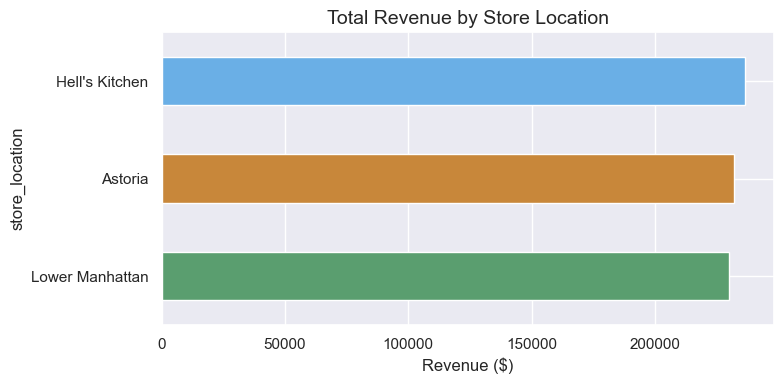

store_location
Lower Manhattan    230057.25
Astoria            232243.91
Hell's Kitchen     236511.17
Name: revenue, dtype: float64


In [6]:
store_rev = df.groupby('store_location')['revenue'].sum().sort_values()

plt.figure(figsize=(8, 4))
store_rev.plot(kind='barh', color=['#5a9e6f','#c8873a','#6aafe6'])
plt.title('Total Revenue by Store Location', fontsize=14)
plt.xlabel('Revenue ($)')
plt.tight_layout(); plt.show()
print(store_rev)

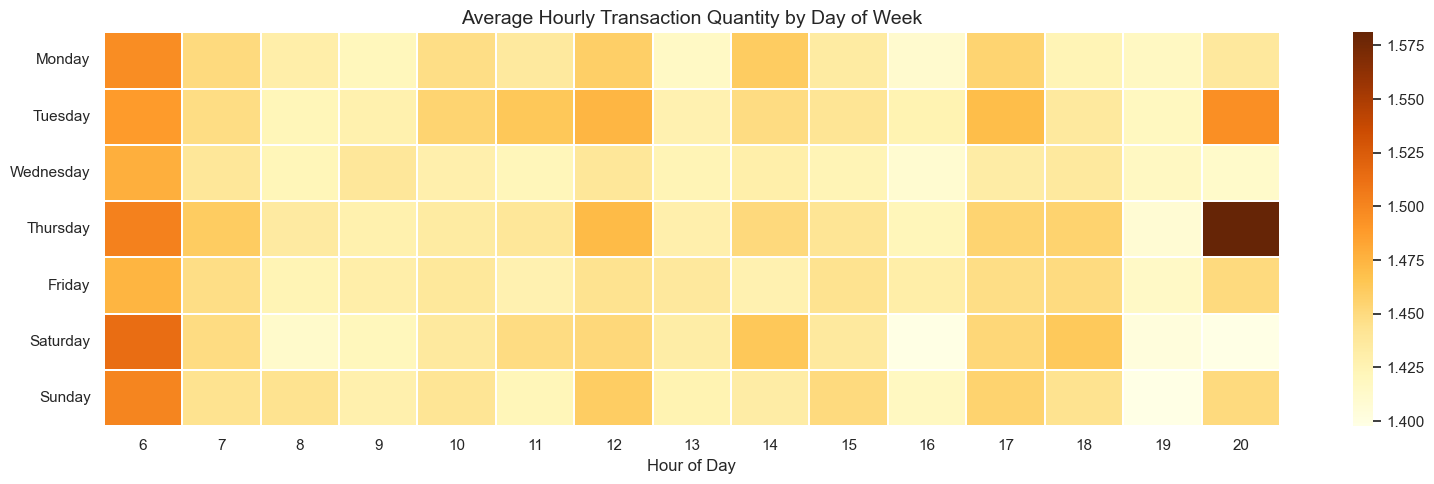

In [7]:
hourly_pivot = df.groupby(['day_of_week', 'hour'])['transaction_qty'].mean().unstack()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
hourly_pivot = hourly_pivot.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(hourly_pivot, cmap='YlOrBr', linewidths=0.3, annot=False)
plt.title('Average Hourly Transaction Quantity by Day of Week', fontsize=14)
plt.xlabel('Hour of Day'); plt.ylabel('')
plt.tight_layout(); plt.show()

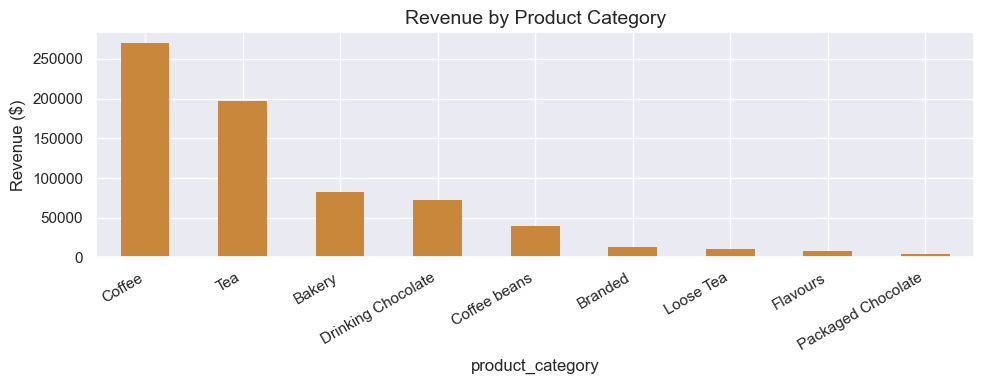

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: revenue, dtype: float64


In [8]:
cat_rev = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
cat_rev.plot(kind='bar', color='#c8873a', edgecolor='none')
plt.title('Revenue by Product Category', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Revenue ($)')
plt.tight_layout(); plt.show()
print(cat_rev)

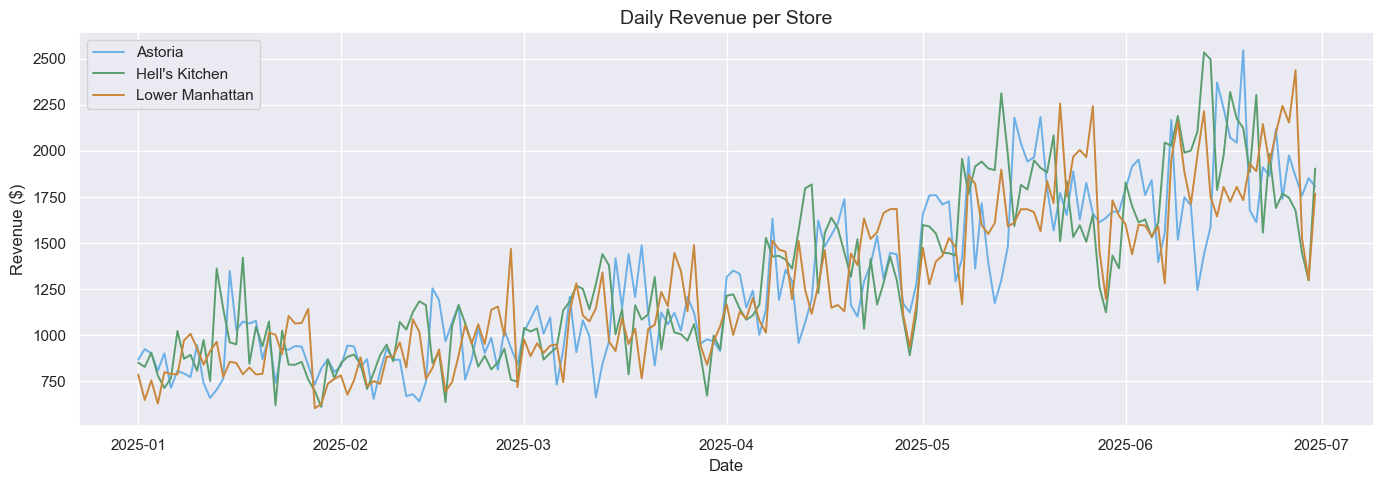

In [9]:
store_daily = df.groupby(['date','store_location'])['revenue'].sum().reset_index()

colors = {'Lower Manhattan':'#c8873a', "Hell's Kitchen":'#5a9e6f', 'Astoria':'#6aafe6'}
plt.figure(figsize=(14,5))
for store, grp in store_daily.groupby('store_location'):
    plt.plot(grp['date'], grp['revenue'], label=store, color=colors[store], linewidth=1.4)
plt.title('Daily Revenue per Store', fontsize=14)
plt.legend(); plt.xlabel('Date'); plt.ylabel('Revenue ($)')
plt.tight_layout(); plt.show()

In [10]:
ts = df.groupby(['date','store_location']).agg(
    revenue=('revenue','sum'),
    quantity=('transaction_qty','sum'),
    transactions=('transaction_id','count')
).reset_index()

ts['date'] = pd.to_datetime(ts['date'])
ts = ts.sort_values(['store_location','date']).reset_index(drop=True)

all_dates  = pd.date_range(ts['date'].min(), ts['date'].max(), freq='D')
all_stores = ts['store_location'].unique()
full_idx   = pd.MultiIndex.from_product([all_dates, all_stores], names=['date','store_location'])
ts = ts.set_index(['date','store_location']).reindex(full_idx, fill_value=0).reset_index()

print('Time-series shape:', ts.shape)
ts.head(10)

Time-series shape: (543, 5)


,date,store_location,revenue,quantity,transactions
0,2025-01-01,Astoria,868.40,277,190
1,2025-01-01,Hell's Kitchen,851.45,270,184
2,2025-01-01,Lower Manhattan,788.35,255,176
3,2025-01-02,Astoria,925.50,301,212
4,2025-01-02,Hell's Kitchen,828.80,272,195
5,2025-01-02,Lower Manhattan,649.05,217,159
6,2025-01-03,Astoria,902.75,287,205
7,2025-01-03,Hell's Kitchen,906.25,295,211
8,2025-01-03,Lower Manhattan,756.00,241,166
9,2025-01-04,Astoria,808.25,262,187


In [11]:
def add_features(df):
    df = df.copy().sort_values(['store_location','date'])
    g = df.groupby('store_location')['revenue']

    df['lag_1']  = g.shift(1)
    df['lag_7']  = g.shift(7)
    df['lag_14'] = g.shift(14)
    df['roll_3'] = g.transform(lambda x: x.shift(1).rolling(3).mean())
    df['roll_7'] = g.transform(lambda x: x.shift(1).rolling(7).mean())

    df['dow']        = df['date'].dt.dayofweek
    df['month']      = df['date'].dt.month
    df['week']       = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)

    df = pd.get_dummies(df, columns=['store_location'], prefix='store')
    return df.dropna().reset_index(drop=True)

ts_feat = add_features(ts)
print('Features shape:', ts_feat.shape)
print('Columns:', ts_feat.columns.tolist())

Features shape: (501, 16)
Columns: ['date', 'revenue', 'quantity', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'roll_3', 'roll_7', 'dow', 'month', 'week', 'is_weekend', 'store_Astoria', "store_Hell's Kitchen", 'store_Lower Manhattan']


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

split_date = ts_feat['date'].max() - pd.Timedelta(days=14)
train = ts_feat[ts_feat['date'] <= split_date]
test  = ts_feat[ts_feat['date'] >  split_date]

feat_cols = [c for c in ts_feat.columns if c not in ['date','revenue','quantity','transactions']]
X_train, y_train = train[feat_cols], train['revenue']
X_test,  y_test  = test[feat_cols],  test['revenue']

print(f'Train: {len(train)} rows ({train["date"].min().date()} to {train["date"].max().date()})')
print(f'Test:  {len(test)}  rows ({test["date"].min().date()} to {test["date"].max().date()})')

Train: 459 rows (2025-01-15 to 2025-06-16)
Test:  42  rows (2025-06-17 to 2025-06-30)


In [13]:
def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / (np.array(y_true) + 1e-9))) * 100

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    m    = mape(y_true, y_pred)
    print(f'{name:28s} | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | MAPE: {m:5.1f}%')
    return {'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(m,1)}

results = []
results.append(eval_model('Naive (lag_1)',    y_test, test['lag_1']))
results.append(eval_model('Moving Avg 7-day', y_test, test['roll_7']))

Naive (lag_1)                | MAE:  243.65 | RMSE:  326.69 | MAPE:  13.3%
Moving Avg 7-day             | MAE:  235.52 | RMSE:  295.60 | MAPE:  13.3%


XGBoost                      | MAE:  204.60 | RMSE:  261.23 | MAPE:  11.1%


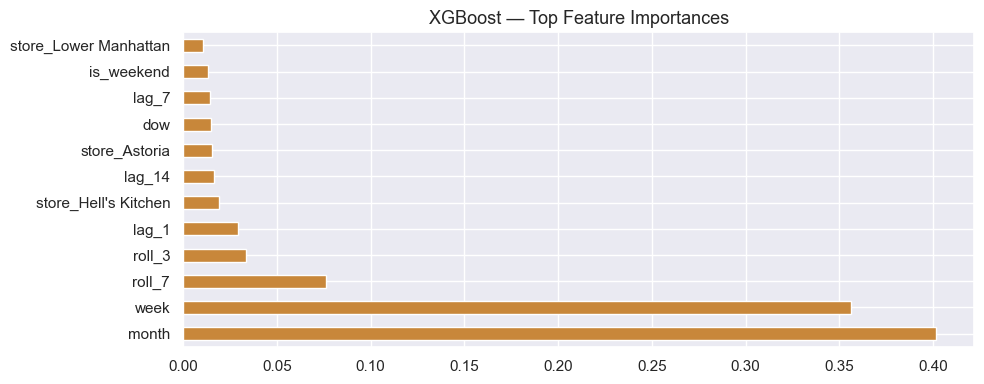

In [14]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(eval_model('XGBoost', y_test, xgb_pred))

feat_imp = pd.Series(xgb.feature_importances_, index=feat_cols).sort_values(ascending=False)[:12]
plt.figure(figsize=(10, 4))
feat_imp.plot(kind='barh', color='#c8873a')
plt.title('XGBoost — Top Feature Importances', fontsize=13)
plt.tight_layout(); plt.show()

15:31:47 - cmdstanpy - INFO - Chain [1] start processing
15:31:48 - cmdstanpy - INFO - Chain [1] done processing


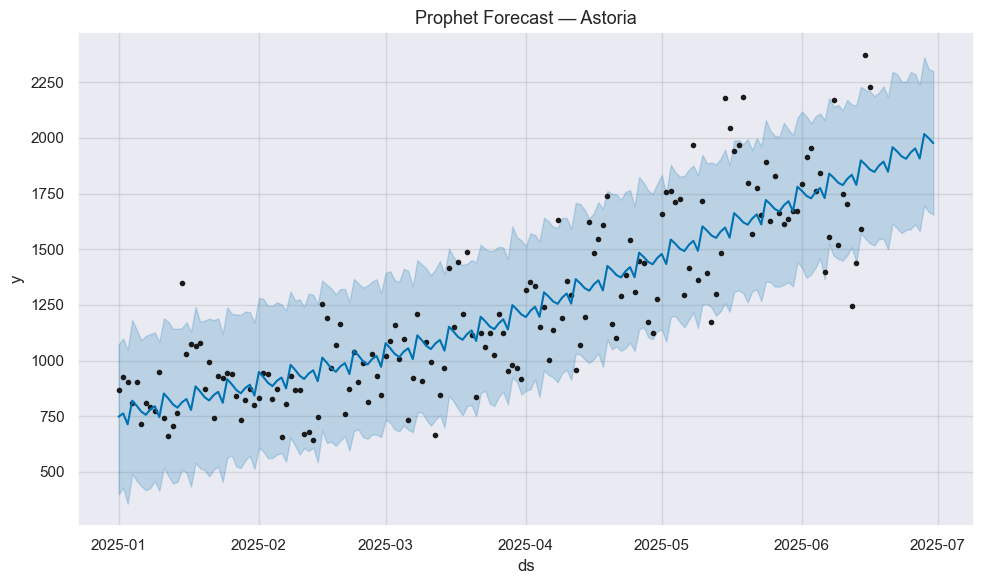

15:31:48 - cmdstanpy - INFO - Chain [1] start processing
15:31:49 - cmdstanpy - INFO - Chain [1] done processing


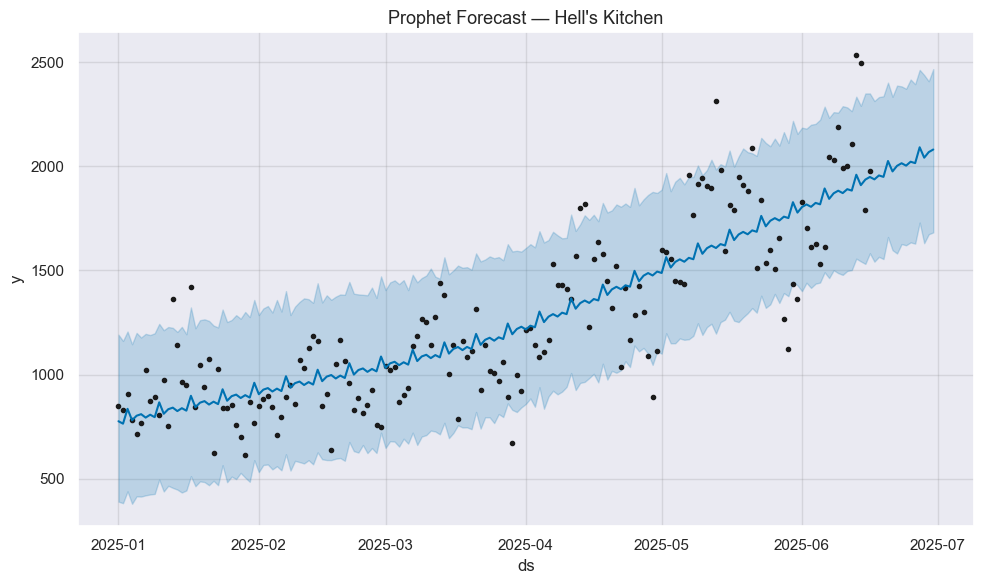

15:31:49 - cmdstanpy - INFO - Chain [1] start processing
15:31:49 - cmdstanpy - INFO - Chain [1] done processing


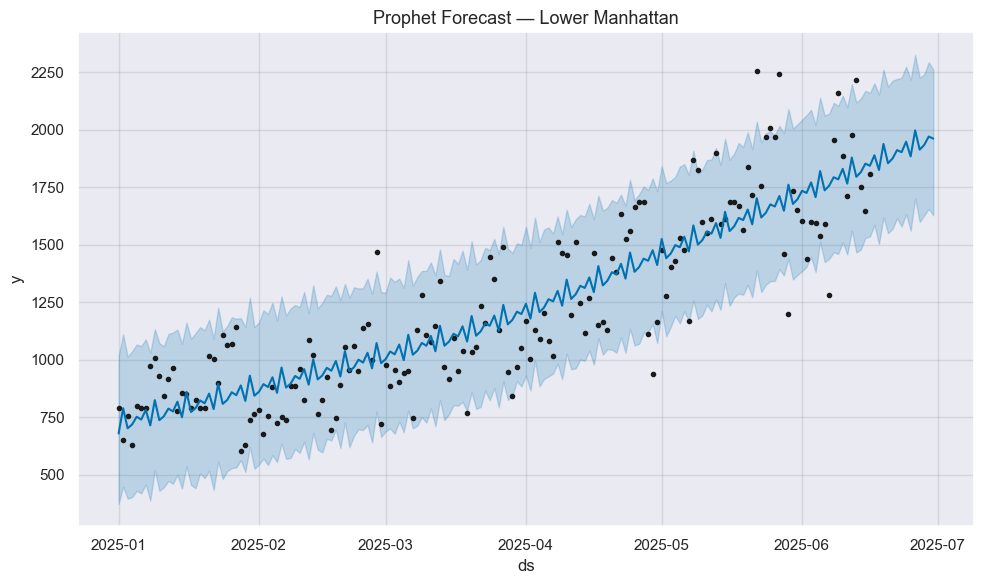

In [15]:
from prophet import Prophet

stores = ts['store_location'].unique()
prophet_results = {}

for sid in stores:
    store_df = ts[ts['store_location'] == sid][['date','revenue']].copy()
    store_df = store_df.rename(columns={'date':'ds','revenue':'y'})
    store_df['ds'] = pd.to_datetime(store_df['ds'])

    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.90
    )
    train_p = store_df[store_df['ds'] <= split_date]
    m.fit(train_p)

    future   = m.make_future_dataframe(periods=14)
    forecast = m.predict(future)
    prophet_results[sid] = (m, forecast)

    fig = m.plot(forecast)
    plt.title(f'Prophet Forecast — {sid}', fontsize=13)
    plt.tight_layout(); plt.show()

In [16]:
for sid in stores:
    _, forecast = prophet_results[sid]
    actual = ts[(ts['store_location'] == sid) & (ts['date'] > split_date)][['date','revenue']].copy()
    actual['date'] = pd.to_datetime(actual['date'])
    merged = actual.merge(forecast[['ds','yhat']], left_on='date', right_on='ds')
    results.append(eval_model(f'Prophet ({sid[:10]})', merged['revenue'], merged['yhat']))

results_df = pd.DataFrame(results)
print('\n📊 MODEL COMPARISON')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)
print('\n✅ Best model (lowest MAE):', results_df.loc[results_df['MAE'].idxmin(), 'Model'])

Prophet (Astoria)            | MAE:  191.99 | RMSE:  247.58 | MAPE:   9.8%
Prophet (Hell's Kit)         | MAE:  322.04 | RMSE:  371.64 | MAPE:  19.2%
Prophet (Lower Manh)         | MAE:  229.28 | RMSE:  297.35 | MAPE:  12.9%

📊 MODEL COMPARISON
               Model    MAE   RMSE  MAPE
       Naive (lag_1) 243.65 326.69  13.3
    Moving Avg 7-day 235.52 295.60  13.3
             XGBoost 204.60 261.23  11.1
   Prophet (Astoria) 191.99 247.58   9.8
Prophet (Hell's Kit) 322.04 371.64  19.2
Prophet (Lower Manh) 229.28 297.35  12.9

✅ Best model (lowest MAE): Prophet (Astoria)


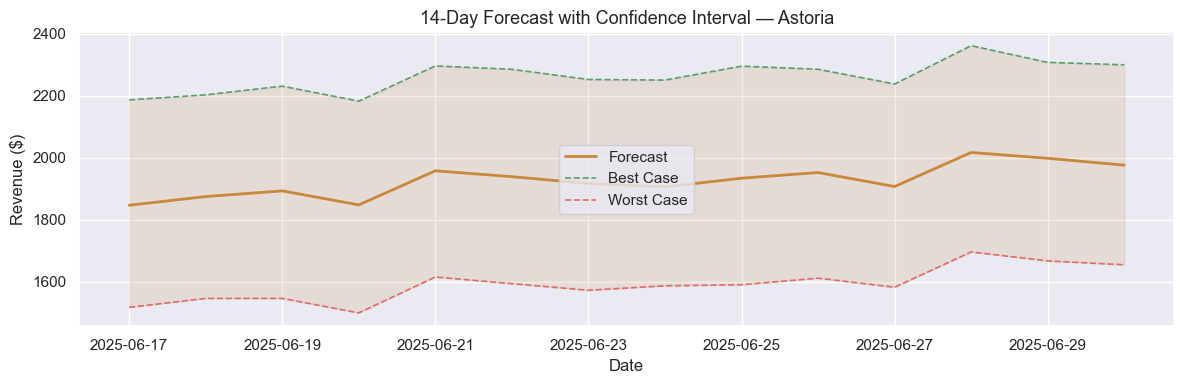

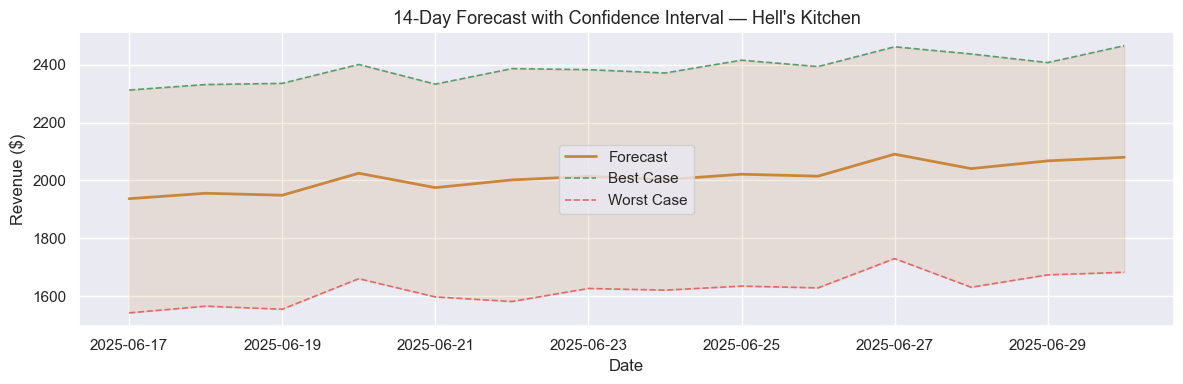

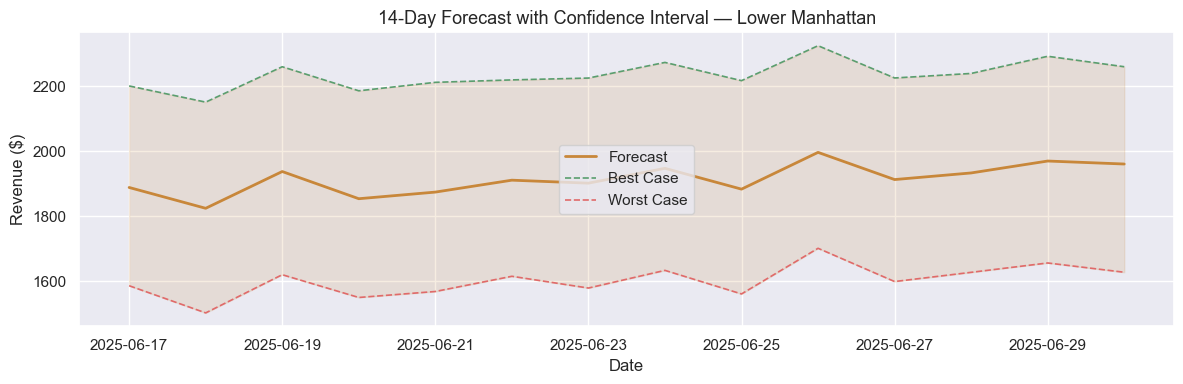

In [17]:
for sid in stores:
    _, forecast = prophet_results[sid]
    fc = forecast.tail(14)

    plt.figure(figsize=(12, 4))
    plt.plot(fc['ds'], fc['yhat'],       color='#c8873a', linewidth=2,   label='Forecast')
    plt.plot(fc['ds'], fc['yhat_upper'], color='#5a9e6f', linewidth=1.2, linestyle='--', label='Best Case')
    plt.plot(fc['ds'], fc['yhat_lower'], color='#e06a6a', linewidth=1.2, linestyle='--', label='Worst Case')
    plt.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.15, color='#c8873a')
    plt.title(f'14-Day Forecast with Confidence Interval — {sid}', fontsize=13)
    plt.legend(); plt.xlabel('Date'); plt.ylabel('Revenue ($)')
    plt.tight_layout(); plt.show()


🔝 Top 10 Peak Revenue Days — Astoria
      date  revenue
2025-06-19  2546.43
2025-06-15  2373.21
2025-06-16  2229.80
2025-05-19  2184.70
2025-05-15  2180.88
2025-06-08  2168.68
2025-06-24  2117.55
2025-06-17  2072.65
2025-06-18  2044.88
2025-05-16  2042.15

🔝 Top 10 Peak Revenue Days — Hell's Kitchen
      date  revenue
2025-06-13  2534.80
2025-06-14  2496.61
2025-06-17  2320.10
2025-05-13  2312.60
2025-06-21  2303.83
2025-06-09  2189.60
2025-06-18  2175.93
2025-06-19  2124.08
2025-06-12  2106.60
2025-05-21  2085.08

🔝 Top 10 Peak Revenue Days — Lower Manhattan
      date  revenue
2025-06-27  2437.40
2025-05-22  2257.06
2025-06-25  2244.95
2025-05-27  2242.85
2025-06-13  2215.11
2025-06-09  2159.08
2025-06-26  2154.70
2025-06-22  2145.95
2025-06-24  2097.75
2025-05-25  2005.30


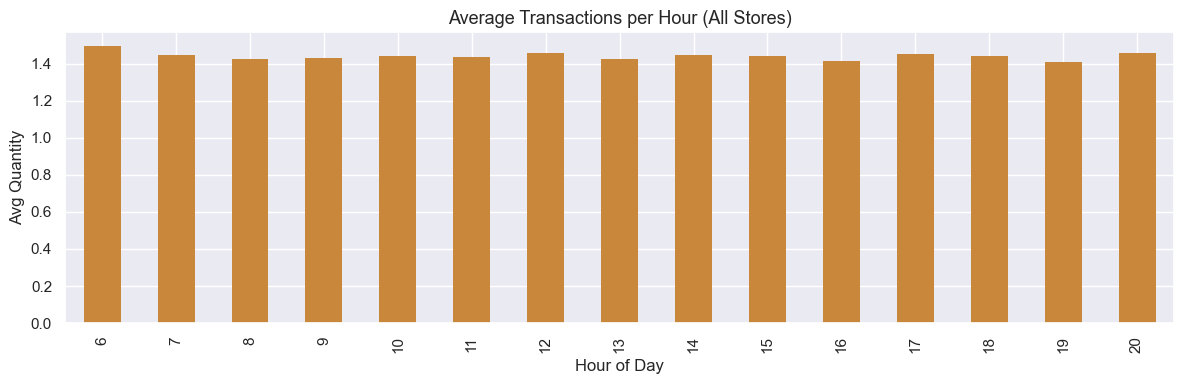

In [18]:
for sid in stores:
    peak = ts[ts['store_location'] == sid].sort_values('revenue', ascending=False).head(10)
    print(f'\n🔝 Top 10 Peak Revenue Days — {sid}')
    print(peak[['date','revenue']].to_string(index=False))

peak_hours = df.groupby('hour')['transaction_qty'].mean()
plt.figure(figsize=(12, 4))
peak_hours.plot(kind='bar', color='#c8873a', edgecolor='none')
plt.title('Average Transactions per Hour (All Stores)', fontsize=13)
plt.xlabel('Hour of Day'); plt.ylabel('Avg Quantity')
plt.tight_layout(); plt.show()